<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1.-로지스틱-회귀" data-toc-modified-id="1.-로지스틱-회귀-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>1. 로지스틱 회귀</a></span></li></ul></div>

## 1. 로지스틱 회귀

In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
body = pd.read_csv(
    "https://raw.githubusercontent.com/ADPclass/ADP_book_ver01/main/data/bodyPerformance.csv"
)

In [2]:
import numpy as np

# gender: 남자=0, 여자=1
body['gender'] = np.where(body['gender'] == 'M', 0, 1)

# 이진 분류용 레이블: A등급=1, 그 외=0
body['class_1'] = np.where(body['class'] == 'A', 1, 0)
body

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,class_1
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,0
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,1
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,0
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,0
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,0
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,0
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,1
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,0


In [3]:
from sklearn.model_selection import train_test_split

feature_columns = list(body.columns.difference(['class', 'class_1']))
X = body[feature_columns]
y = body['class_1']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1
)
print(X_train.shape, X_test.shape)

(9375, 11) (4018, 11)


In [4]:
from sklearn.linear_model import LogisticRegression

logR = LogisticRegression(random_state=45, solver='liblinear')
logR.fit(X_train, y_train)

LogisticRegression(random_state=45, solver='liblinear')

In [5]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

pred = logR.predict(X_test)

acc = accuracy_score(y_test, pred)
prc = precision_score(y_test, pred)
rcll = recall_score(y_test, pred)
f1 = f1_score(y_test, pred)

print(confusion_matrix(y_test, pred))
print('\n')
print('정확도\t{}%'.format(round(acc*100, 2)))
print('정밀도\t{}%'.format(round(prc*100, 2)))
print('재현율\t{}%'.format(round(rcll*100, 2)))
print('F1\t{}%'.format(round(f1*100, 2)))

[[2767  247]
 [ 349  655]]


정확도	85.17%
정밀도	72.62%
재현율	65.24%
F1	68.73%


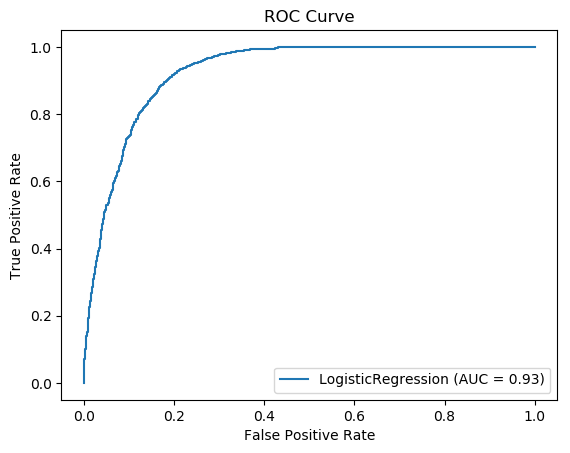

In [6]:
from sklearn.metrics import plot_roc_curve
import matplotlib.pyplot as plt

plot_roc_curve(logR, X_test, y_test)

plt.title('ROC Curve')
plt.show()

In [7]:
# A=0, B=1, C=2, D=3 으로 매핑
mapping = {'A': 0, 'B': 1, 'C': 2, 'D': 3}
body['class_2'] = body['class'].map(mapping)
body

,age,gender,height_cm,weight_kg,body fat_%,diastolic,systolic,gripForce,sit and bend forward_cm,sit-ups counts,broad jump_cm,class,class_1,class_2
0,27.0,0,172.3,75.24,21.3,80.0,130.0,54.9,18.4,60.0,217.0,C,0,2
1,25.0,0,165.0,55.80,15.7,77.0,126.0,36.4,16.3,53.0,229.0,A,1,0
2,31.0,0,179.6,78.00,20.1,92.0,152.0,44.8,12.0,49.0,181.0,C,0,2
3,32.0,0,174.5,71.10,18.4,76.0,147.0,41.4,15.2,53.0,219.0,B,0,1
4,28.0,0,173.8,67.70,17.1,70.0,127.0,43.5,27.1,45.0,217.0,B,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13388,25.0,0,172.1,71.80,16.2,74.0,141.0,35.8,17.4,47.0,198.0,C,0,2
13389,21.0,0,179.7,63.90,12.1,74.0,128.0,33.0,1.1,48.0,167.0,D,0,3
13390,39.0,0,177.2,80.50,20.1,78.0,132.0,63.5,16.4,45.0,229.0,A,1,0
13391,64.0,1,146.1,57.70,40.4,68.0,121.0,19.3,9.2,0.0,75.0,D,0,3


In [8]:
body.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13393 entries, 0 to 13392
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      13393 non-null  float64
 1   gender                   13393 non-null  int32  
 2   height_cm                13393 non-null  float64
 3   weight_kg                13393 non-null  float64
 4   body fat_%               13393 non-null  float64
 5   diastolic                13393 non-null  float64
 6   systolic                 13393 non-null  float64
 7   gripForce                13393 non-null  float64
 8   sit and bend forward_cm  13393 non-null  float64
 9   sit-ups counts           13393 non-null  float64
 10  broad jump_cm            13393 non-null  float64
 11  class                    13393 non-null  object 
 12  class_1                  13393 non-null  int32  
 13  class_2                  13393 non-null  int64  
dtypes: float64(10), int32(

In [9]:
from sklearn.model_selection import train_test_split
feature_columns = list(body.columns.difference(['class','class_1','class_2']))
X = body[feature_columns]
y = body['class_2']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, train_size=0.7, random_state=1
)
print(X_train.shape, X_test.shape)

(9375, 11) (4018, 11)


In [10]:
from sklearn.linear_model import LogisticRegression

# 소프트맥스 회귀 활성화
softm = LogisticRegression(
    multi_class='multinomial',
    solver='newton-cg',
    random_state=45,
)
softm.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=45,
                   solver='newton-cg')

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score

pred = softm.predict(X_test)
acc = accuracy_score(y_test, pred)

print(confusion_matrix(y_test, pred))
print('\n')
print('정확도\t{}%'.format(round(acc*100, 2)))

[[745 236  23   0]
 [242 441 293  28]
 [ 76 216 530 183]
 [ 11  58 150 786]]


정확도	62.27%


In [12]:
# 마지막 행 데이터 예측 클래스
pred_sample = softm.predict([X_test.iloc[-1, :]])
# 각 클래스에 속할 확률
prb_sample = softm.predict_proba([X_test.iloc[-1, :]])

print('예측 클래스: ', pred_sample[0])
print('실제 클래스: ', y_test.iloc[-1])
print('각 클래스에 속할 확률', prb_sample[0])

예측 클래스:  0
실제 클래스:  0
각 클래스에 속할 확률 [7.46877967e-01 2.23407518e-01 2.92272103e-02 4.87304679e-04]


In [13]:
logR.coef_

array([[ 0.08409257, -0.04343403,  0.01432989, -0.0059666 ,  2.46948174,
         0.10047223, -0.06673523,  0.19375738,  0.12064993, -0.00369976,
        -0.04901549]])

In [14]:
np.exp(logR.coef_)

array([[ 1.08772958,  0.95749572,  1.01443306,  0.99405117, 11.8163213 ,
         1.10569294,  0.93544285,  1.21380175,  1.12822989,  0.99630707,
         0.95216638]])